# Exploratory Analysis and Figures

## 1 Heatmap of RMSE over Parameter Space

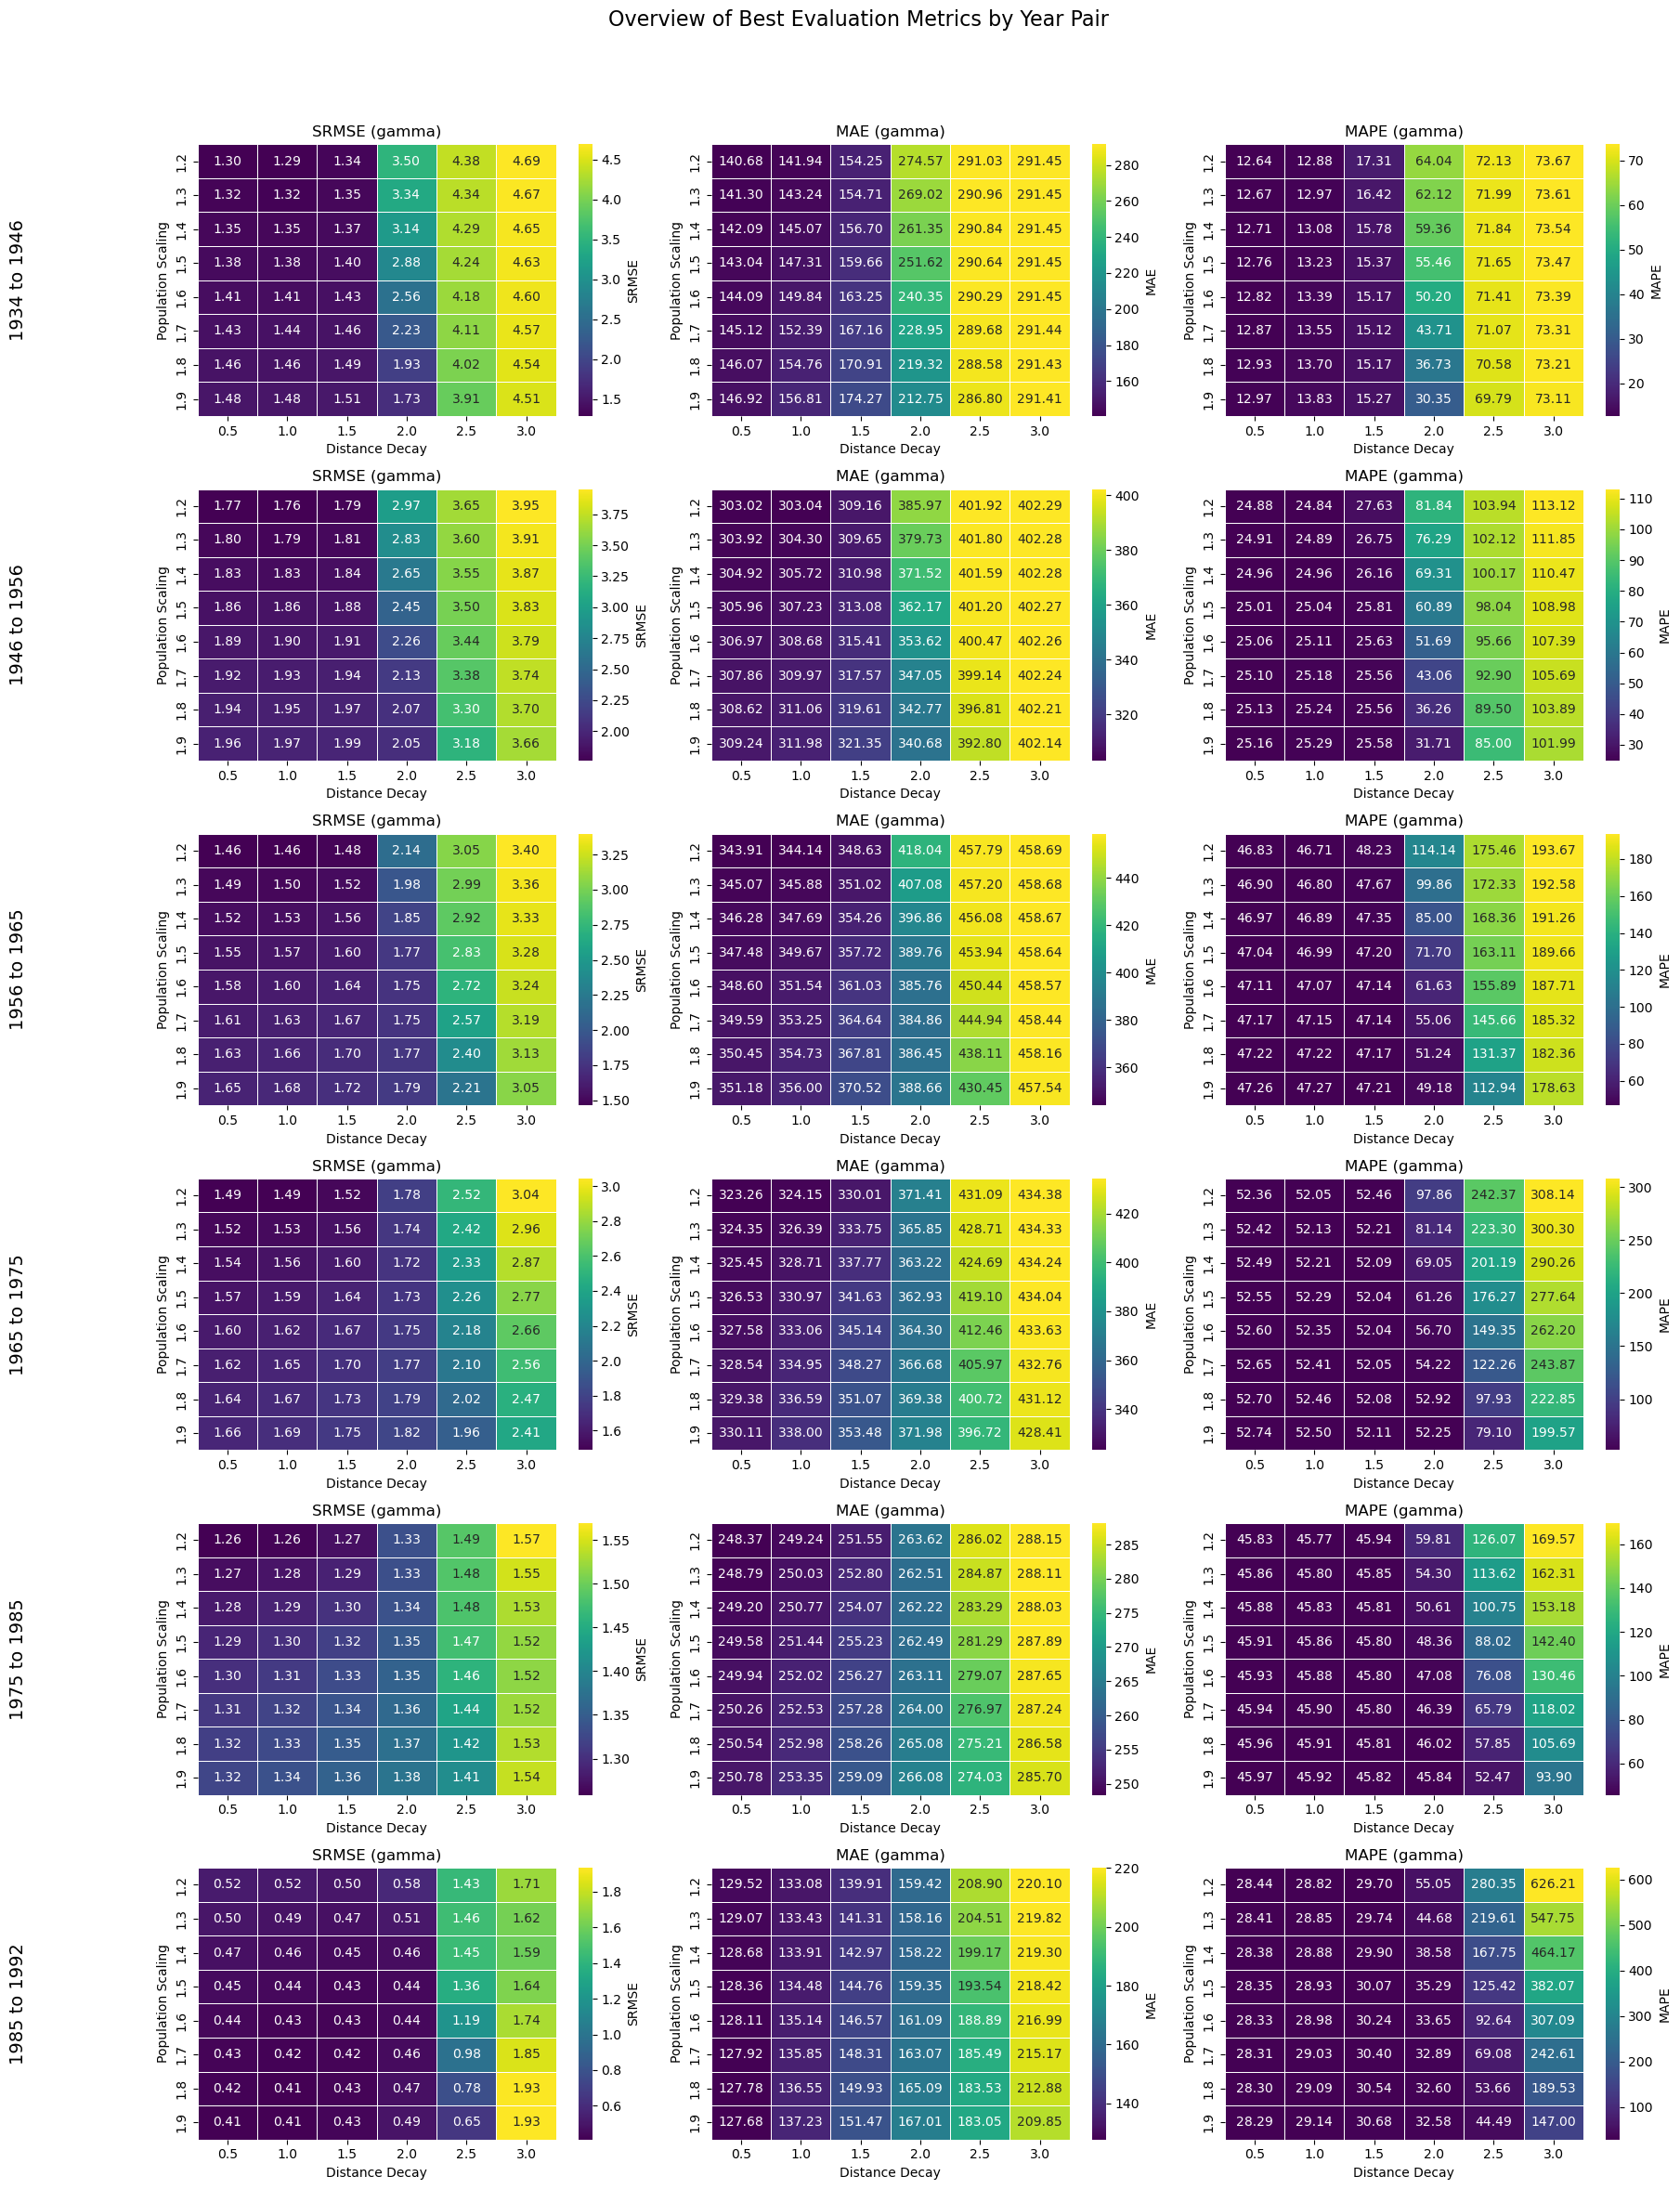

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np

# Load the detailed interval metrics CSV file (adjust the file path as needed)
interval_df = pd.read_csv(r"D:\PhD\SIM_Model_BG_unconstrained_iterative\predictions_by_interval_evaluation_16042025.csv")

# Ensure that the parameter columns are floats
interval_df['population_scaling'] = interval_df['population_scaling'].astype(float)
interval_df['distance_decay'] = interval_df['distance_decay'].astype(float)

# Get unique year pairs (each as a tuple: (year_start, year_end))
year_pairs = interval_df[['year_start', 'year_end']].drop_duplicates().reset_index(drop=True)

# Define the evaluation metrics to visualize
metrics = ['srmse', 'mae', 'mape']

# Define the output directory for figures and create it if it doesn't exist
fig_out_dir = os.path.join("output_figures")
os.makedirs(fig_out_dir, exist_ok=True)

# For each year pair, select the best model type (based on lowest RMSE)
best_configs = {}
for idx, row in year_pairs.iterrows():
    yr_start, yr_end = row['year_start'], row['year_end']
    subset_year = interval_df[(interval_df['year_start'] == yr_start) & 
                                (interval_df['year_end'] == yr_end)]
    best_model = subset_year.groupby('model_type')['rrmse'].min().idxmin()
    best_configs[(yr_start, yr_end)] = best_model

# Create a combined figure: one row per year pair and one column per metric.
n_year_pairs = len(year_pairs)
n_metrics = len(metrics)
fig, axes = plt.subplots(n_year_pairs, n_metrics, figsize=(6*n_metrics, 4*n_year_pairs), squeeze=False)

# Loop over each year pair and plot the heatmaps for the best model type.
for idx, row in year_pairs.iterrows():
    yr_start, yr_end = row['year_start'], row['year_end']
    best_model = best_configs[(yr_start, yr_end)]
    
    # Filter the data for this year pair and best model type.
    subset_best = interval_df[(interval_df['year_start'] == yr_start) & 
                                (interval_df['year_end'] == yr_end) &
                                (interval_df['model_type'] == best_model)]
    
    for j, metric in enumerate(metrics):
        # Create a pivot table with population_scaling as rows and distance_decay as columns.
        pivot = subset_best.pivot_table(index='population_scaling', 
                                        columns='distance_decay', 
                                        values=metric, 
                                        aggfunc='mean')
        # For R2, reverse the colormap so that higher values are "better" (i.e. visually appealing)
        current_cmap = "viridis_r" if metric.lower() == "r2" else "viridis"
        ax = axes[idx, j]
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap=current_cmap,
                    cbar_kws={'label': metric.upper()}, ax=ax,
                    linewidths=0.5, linecolor='white')
        ax.set_title(f"{metric.upper()} ({best_model})", fontsize=12)
        ax.set_xlabel("Distance Decay", fontsize=10)
        ax.set_ylabel("Population Scaling", fontsize=10)
    
    # Add a label for the row (year pair) to the left of the subplots.
    row_label = f"{yr_start[-4:]} to {yr_end[-4:]}"
    axes[idx, 0].text(-0.5, 0.5, row_label, 
                        va='center', ha='center', fontsize=14, rotation=90,
                        transform=axes[idx, 0].transAxes)

fig.suptitle("Overview of Best Evaluation Metrics by Year Pair", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the combined figure as a high-resolution PNG.
fig_filename = "combined_evaluation_overview2.png"
fig.savefig(os.path.join(fig_out_dir, fig_filename), dpi=300, bbox_inches='tight')
plt.show()

## 2. Create latex table for best parameter settings by year pair

In [ ]:
import pandas as pd

# # Load the detailed interval metrics CSV file (adjust the path if needed)
# interval_df = pd.read_csv("SIM_Interval_Metrics_BG.csv")

# Ensure that the parameter columns are floats
interval_df['population_scaling'] = interval_df['population_scaling'].astype(float)
interval_df['distance_decay'] = interval_df['distance_decay'].astype(float)

# For each unique year pair, select the best parameter configuration based on the lowest RMSE.
best_params = interval_df.loc[interval_df.groupby(['year_start', 'year_end'])['rrmse'].idxmin()].reset_index(drop=True)

# Adjust the year columns to only include the last 4 digits.
best_params['year_start'] = best_params['year_start'].apply(lambda x: str(x)[-4:])
best_params['year_end'] = best_params['year_end'].apply(lambda x: str(x)[-4:])

# Order the table by the start year.
best_params = best_params.sort_values(by='year_start')

# Select only the desired columns.
table = best_params[['year_start', 'year_end', 'population_scaling', 'distance_decay', 'model_type', 'rrmse', 'mae', 'mape']]

# Print the table.
print(table)

# Convert the table to LaTeX format.
latex_table = table.to_latex(index=False, float_format="%.4f")
print(latex_table)

## fig. 5 visualise the flows by year pair

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File path to your aggregated flows geoparquet file.
aggregated_file = r"D:\PhD\SIM_Model_BG_unconstrained_iterative\OD_Flows_by_YearPair\Aggregated_OD_Flows_with_all_extras_and_geom.parquet"

# Load the aggregated flows as a GeoDataFrame.
gdf = gpd.read_parquet(aggregated_file)

# Ensure that the necessary extra columns are available.
# For example, we expect: origin_region, r_mean, r_median, etc.
print("Aggregated flows shape:", gdf.shape)
print(gdf.columns)

In [ ]:
# Extract unique year pairs.
year_pairs = gdf[['year_start', 'year_end']].drop_duplicates().copy()

# Replace year_start and year_end with their last 4 characters as integers.
year_pairs['year_start'] = year_pairs['year_start'].astype(str).str[-4:].astype(int)
year_pairs['year_end'] = year_pairs['year_end'].astype(str).str[-4:].astype(int)

# Sort by year_start.
year_pairs = year_pairs.sort_values(by='year_start').reset_index(drop=True)

print("Year pairs available (sorted by year_start):")
print(year_pairs)

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import numpy as np
import json

# --- Load your aggregated flows GeoDataFrame (assume gdf is already loaded) ---
# For example:
# gdf = gpd.read_parquet("path/to/Aggregated_OD_Flows_with_all_extras_and_geom.parquet")

# --- Filter flows: keep only flows with net_migration > 5 ---
gdf_filtered = gdf[gdf['net_migration'] > 1].copy()

# --- Create new columns for the last 4 digits of year_start and year_end ---
gdf_filtered['year_start_4'] = gdf_filtered['year_start'].astype(str).str[-4:].astype(int)
gdf_filtered['year_end_4']   = gdf_filtered['year_end'].astype(str).str[-4:].astype(int)

# --- Identify unique year pairs using the new columns ---
year_pairs = gdf_filtered[['year_start_4', 'year_end_4']].drop_duplicates().copy()
year_pairs = year_pairs.sort_values(by='year_start_4').reset_index(drop=True)
print("Year pairs available (sorted by year_start):")
print(year_pairs)

# --- Load Bulgaria's outline from your provided GeoJSON using json and GeoDataFrame.from_features ---
geojson_path = r"C:\Users\pietg\OneDrive - University of Glasgow\PhD Research\Phd_Data\Scripts(Python, SQL, ArcGiS)\Python\agile_sim_model\Agile_SIM_bg_tr-1\input_files\geoBoundaries-BGR-ADM0_simplified.geojson"
with open(geojson_path, 'r') as f:
    geojson_data = json.load(f)
bulgaria = gpd.GeoDataFrame.from_features(geojson_data["features"])
if bulgaria.crs is None:
    bulgaria.set_crs(epsg=4326, inplace=True)
else:
    bulgaria = bulgaria.to_crs(epsg=4326)

# --- Global normalization for color mapping (using all filtered flows) ---
# Clip the upper bound at the 95th percentile to reduce the impact of extreme outliers.
overall_min_flow = gdf_filtered['net_migration'].min()
overall_max_flow = gdf_filtered['net_migration'].quantile(0.85)
global_norm = mpl.colors.Normalize(vmin=overall_min_flow, vmax=overall_max_flow)

# --- Create a combined figure with 3 rows x 2 columns (portrait A4: 8.27 x 11.69 inches) ---
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8.27, 11.69))
axes = axes.flatten()

# Define the 'Reds' colormap.
cmap = plt.get_cmap('Reds')

# Define a function to compute line width using square-root scaling relative to the local range.
def get_linewidth(flow, local_min, local_max):
    if local_max == local_min:
        return 1.5
    norm_flow = (flow - local_min) / (local_max - local_min)
    return 0.5 + 2.0 * np.sqrt(norm_flow)

for i, (_, yp) in enumerate(year_pairs.iterrows()):
    ys = yp['year_start_4']
    ye = yp['year_end_4']
    ax = axes[i]
    
    # Subset flows for the current year pair using the new columns.
    gdf_year = gdf_filtered[(gdf_filtered['year_start_4'] == ys) & (gdf_filtered['year_end_4'] == ye)].copy()
    if gdf_year.empty:
        print(f"No flows for {ys}-{ye} after filtering; skipping.")
        continue
    
    # Compute local min and max net migration for line width scaling.
    local_min = gdf_year['net_migration'].min()
    local_max = gdf_year['net_migration'].max()
    
    # Sort flows so that those with higher net migration are plotted last.
    gdf_year = gdf_year.sort_values(by='net_migration', ascending=True)
    
    # Plot Bulgaria's outline as background.
    bulgaria.boundary.plot(ax=ax, color='black', linewidth=1)
    
    # Plot each flow as a LineString.
    for _, row in gdf_year.iterrows():
        geom = row['geometry']
        if geom is not None:
            flow = row['net_migration']
            lw = get_linewidth(flow, local_min, local_max)
            # For color mapping, clip the flow to the global_norm limits.
            clipped_flow = np.clip(flow, overall_min_flow, overall_max_flow)
            color = cmap(global_norm(clipped_flow))
            ax.plot(*geom.xy, color=color, linewidth=lw, alpha=0.2)
    
    ax.set_title(f"{ys} - {ye}", fontsize=10)
    ax.set_xlabel("Longitude", fontsize=8)
    ax.set_ylabel("Latitude", fontsize=8)
    
    # Set equal aspect ratio.
    ax.set_aspect('equal', adjustable='datalim')
    
    # Annotate each subplot with its local net migration range.
    annotation = f"Range:\n{local_min:.1f} to {local_max:.1f}"
    ax.text(0.05, 0.95, annotation, transform=ax.transAxes, fontsize=7,
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))
    
# Remove any unused axes.
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# --- Add a continuous vertical colorbar on the right side of the figure ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=global_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label("Net Migration (Clipped to 85th Percentile)", fontsize=10)

combined_image_file = "Combined_Figure5_NetworkFlows.png"
output_path = r"C:\Users\pietg\OneDrive - University of Glasgow\PhD Research\Phd_Data\Scripts(Python, SQL, ArcGiS)\Python\agile_sim_model\Agile_SIM_bg_tr-1\output_figures\Combined_Figure5_NetworkFlows.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Combined image saved as {output_path}")


## fig. 6 Histograms and density plots showing settlement-level inflows, outflows, and net migration. 

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ---------------------------
# 1. Load and Prepare Data
# ---------------------------

# # Load your aggregated OD flows GeoDataFrame (OD pair level)
# aggregated_file = r"path\to\Aggregated_OD_Flows_with_all_extras_and_geom.parquet"
# gdf = gpd.read_parquet(aggregated_file)

# Create new columns for the last 4 digits of year_start and year_end
gdf['year_start_4'] = gdf['year_start'].astype(str).str[-4:]
gdf['year_end_4']   = gdf['year_end'].astype(str).str[-4:]
# Create a combined "year_pair" column (e.g., "1985-1992")
gdf['year_pair'] = gdf['year_start_4'] + "-" + gdf['year_end_4']

# ---------------------------
# 2. Aggregate Settlement Flows
# ---------------------------

# For inflows: group by year_pair and destination settlement.
inflow_df = gdf.groupby(['year_pair', 'destination_ekatte'], as_index=False).agg({'inflow': 'sum'})
inflow_df = inflow_df.rename(columns={'destination_ekatte': 'ekatte_id'})

# For outflows: group by year_pair and origin settlement.
outflow_df = gdf.groupby(['year_pair', 'origin_ekatte'], as_index=False).agg({'outflow': 'sum'})
outflow_df = outflow_df.rename(columns={'origin_ekatte': 'ekatte_id'})

# Merge the two on year_pair and settlement identifier.
settlement_df = pd.merge(inflow_df, outflow_df, on=['year_pair', 'ekatte_id'], how='outer')
settlement_df['inflow'] = settlement_df['inflow'].fillna(0)
settlement_df['outflow'] = settlement_df['outflow'].fillna(0)
settlement_df['net_migration'] = settlement_df['inflow'] - settlement_df['outflow']

print("Settlement-level aggregated flows (first few rows):")
print(settlement_df.head())

# ---------------------------
# 3. Create Log-Scaled Variables
# ---------------------------

# For inflow and outflow, use np.log1p (which is defined for non-negative values).
settlement_df['log_inflow'] = settlement_df['inflow'].apply(np.log1p)
settlement_df['log_outflow'] = settlement_df['outflow'].apply(np.log1p)

# For net migration, define a symmetric log transform.
def symmetric_log(x):
    if x >= 0:
        return np.log1p(x)
    else:
        return -np.log1p(abs(x))
    
settlement_df['log_net'] = settlement_df['net_migration'].apply(symmetric_log)

# ---------------------------
# 4. Create Figure 6: Histograms & Density Plots by Year Pair
# ---------------------------

# Identify unique year pairs (sorted)
year_pairs = sorted(settlement_df['year_pair'].unique())
n_pairs = len(year_pairs)
print("Unique year pairs:", year_pairs)

# Create a figure with one row per year pair and 3 columns (inflow, outflow, net migration)
fig, axes = plt.subplots(nrows=n_pairs, ncols=3, figsize=(15, 4 * n_pairs), sharex=False, sharey=False)

# Ensure axes is a 2D array even if there's only one row.
if n_pairs == 1:
    axes = [axes]

for i, yp in enumerate(year_pairs):
    sub_df = settlement_df[settlement_df['year_pair'] == yp]
    
    # Inflow panel: log(1+inflow)
    ax_inflow = axes[i][0]
    sns.histplot(sub_df['log_inflow'], bins=30, kde=True, ax=ax_inflow, color='blue', edgecolor='black', alpha=0.7)
    ax_inflow.set_title(f"{yp} - log(1+Inflow)", fontsize=12)
    ax_inflow.set_xlabel("log(1 + Inflow)", fontsize=10)
    ax_inflow.set_ylabel("Frequency", fontsize=10)
    
    # Outflow panel: log(1+outflow)
    ax_outflow = axes[i][1]
    sns.histplot(sub_df['log_outflow'], bins=30, kde=True, ax=ax_outflow, color='red', edgecolor='black', alpha=0.7)
    ax_outflow.set_title(f"{yp} - log(1+Outflow)", fontsize=12)
    ax_outflow.set_xlabel("log(1 + Outflow)", fontsize=10)
    ax_outflow.set_ylabel("Frequency", fontsize=10)
    
    # Net Migration panel: symmetric log transform
    ax_net = axes[i][2]
    sns.histplot(sub_df['log_net'], bins=30, kde=True, ax=ax_net, color='green', edgecolor='black', alpha=0.7)
    ax_net.set_title(f"{yp} - log Transformed Net Migration", fontsize=12)
    ax_net.set_xlabel("Symmetric log(Net Migration)", fontsize=10)
    ax_net.set_ylabel("Frequency", fontsize=10)

plt.tight_layout()

# Save the figure
output_path = r"C:\Users\pietg\OneDrive - University of Glasgow\PhD Research\Phd_Data\Scripts(Python, SQL, ArcGiS)\Python\agile_sim_model\Agile_SIM_bg_tr-1\output_maps\Figure6_Histograms_Density_Log.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure 6 saved as", output_path)


# create box and wisker plot for ruggedness quantile groups

In [1]:
import duckdb
import os

# paths
input_pq  = r"D:\PhD\SIM_Model_BG_unconstrained_iterative\OD_Flows_by_YearPair_srmse\Aggregated_OD_Flows_with_all_extras_and_geom.parquet"
output_pq = r"D:\PhD\SIM_Model_BG_unconstrained_iterative\OD_Flows_by_YearPair_srmse\quantiled_netmig.parquet"

# connect (in‐process)
con = duckdb.connect()

# perform NTILE and select only the columns we need for plotting
con.execute(f"""
COPY (
  WITH base AS (
    SELECT
      year_start,
      year_end,
      NTILE(5) OVER (
        PARTITION BY year_start, year_end
        ORDER BY origin_r_mean
      ) AS rugged_quantile,
      net_migration
    FROM read_parquet('{input_pq.replace("'", "''")}')
  )
  SELECT
    year_start,
    year_end,
    rugged_quantile,
    net_migration
  FROM base
) TO '{output_pq.replace("'", "''")}' (FORMAT PARQUET);
""")

print("Wrote quantile‐grouped data to", output_pq)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Wrote quantile‐grouped data to D:\PhD\SIM_Model_BG_unconstrained_iterative\OD_Flows_by_YearPair_srmse\quantiled_netmig.parquet


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# ---------------------------
# 1. Load reduced Parquet & plot
# ---------------------------
df = pd.read_parquet(output_pq)

# Create a 'year_pair' label (e.g. "2000-2010")
df['year_pair'] = (
    df['year_start'].astype(str).str[-4:]
    + "-"
    + df['year_end'].astype(str).str[-4:]
)

# Plot settings
year_pairs = sorted(df['year_pair'].unique())
n_pairs    = len(year_pairs)
n_cols     = 3
n_rows     = math.ceil(n_pairs / n_cols)
groups     = [1, 2, 3, 4, 5]  # NTILE labels

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols*5, n_rows*4),
    sharey=False,             # each panel gets its own y-scale
    constrained_layout=True
)
axes = axes.flatten()

for ax, yp in zip(axes, year_pairs):
    sub = df[df['year_pair'] == yp]
    # gather net_migration arrays for each quantile
    data = [
        sub.loc[sub['rugged_quantile'] == q, 'net_migration']
           .dropna()
           .values
        for q in groups
    ]
    ax.boxplot(
        data,
        labels=[f"Q{q}" for q in groups],
        whis=(5, 95),            # whiskers at 5th and 95th percentile
        showfliers=False,        # hide points beyond whiskers
        patch_artist=True,       # enable box facecolor
        boxprops=dict(facecolor='lightgrey'),
        medianprops=dict(color='red')
    )
    ax.set_title(yp)
    ax.set_xlabel("Ruggedness Quantile")
    ax.set_ylabel("Net Migration")

# Remove any unused axes if (n_pairs % n_cols != 0)
for ax in axes[n_pairs:]:
    fig.delaxes(ax)

# fig.suptitle(
#     "Net Migration by Ruggedness Quantile\n(Box & Whisker, 5th–95th percentile whiskers)",
#     y=1.02
# )

# Save & show
output_png = r"D:\PhD\SIM_Model_BG_unconstrained_iterative\OD_Flows_by_YearPair_srmse\Figure9_BoxWhisker_5th95th_V3.png"
plt.savefig(output_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved as {output_png}")
